$ \Huge \frac{d\psi}{dx} = e^{-x^2/2}\sin(x) - \psi^2 + x^2 e^{-(x-1)^2/0.1} \\
 \Large \quad x \in [0, 20],
 \Large \quad \psi(0) = 0$

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Initial conditions
x_start = 0  # Starting x value
x_end = 20   # Ending x value for the solution
Psi_0 = 0    # Initial condition Psi(0) = Psi_0

# The collocation points
x = torch.Tensor(np.linspace(0, 20, 1000)).reshape(-1,1)
x=x.to(device)

In [ ]:
# N is a Neural Network
N = nn.Sequential(nn.Linear(1, 10), nn.Sigmoid(), nn.Linear(10,1, bias=False))

model=N.to(device)


# The Psi_app function--the solution: what neural network will approximate
def Psi_app(x):
    return N(x)


# The right hand side function
def f(x, Psi):
    return torch.exp(-x**2 / 2) * torch.sin(x) -Psi**2 + x**2 * torch.exp(-(x-1)**2 / 0.1)

def loss(x):
    x.requires_grad = True            # gradient tracking active for backpropogation step


    Psi_d_x = torch.autograd.grad(Psi_app(x), x, grad_outputs=torch.ones_like(Psi_app(x)),
                                  create_graph=True)[0]

    ode_residual = Psi_d_x - f(x, Psi_app(x))     # (LHS prediction-RHS prediction)
    loss_ode = torch.mean(ode_residual ** 2)


    x0 = torch.tensor([[0.0]], requires_grad=True).to(device)
    loss_ic = (Psi_app(x0) - 0) ** 2       #initial condition residual

    return loss_ode + loss_ic

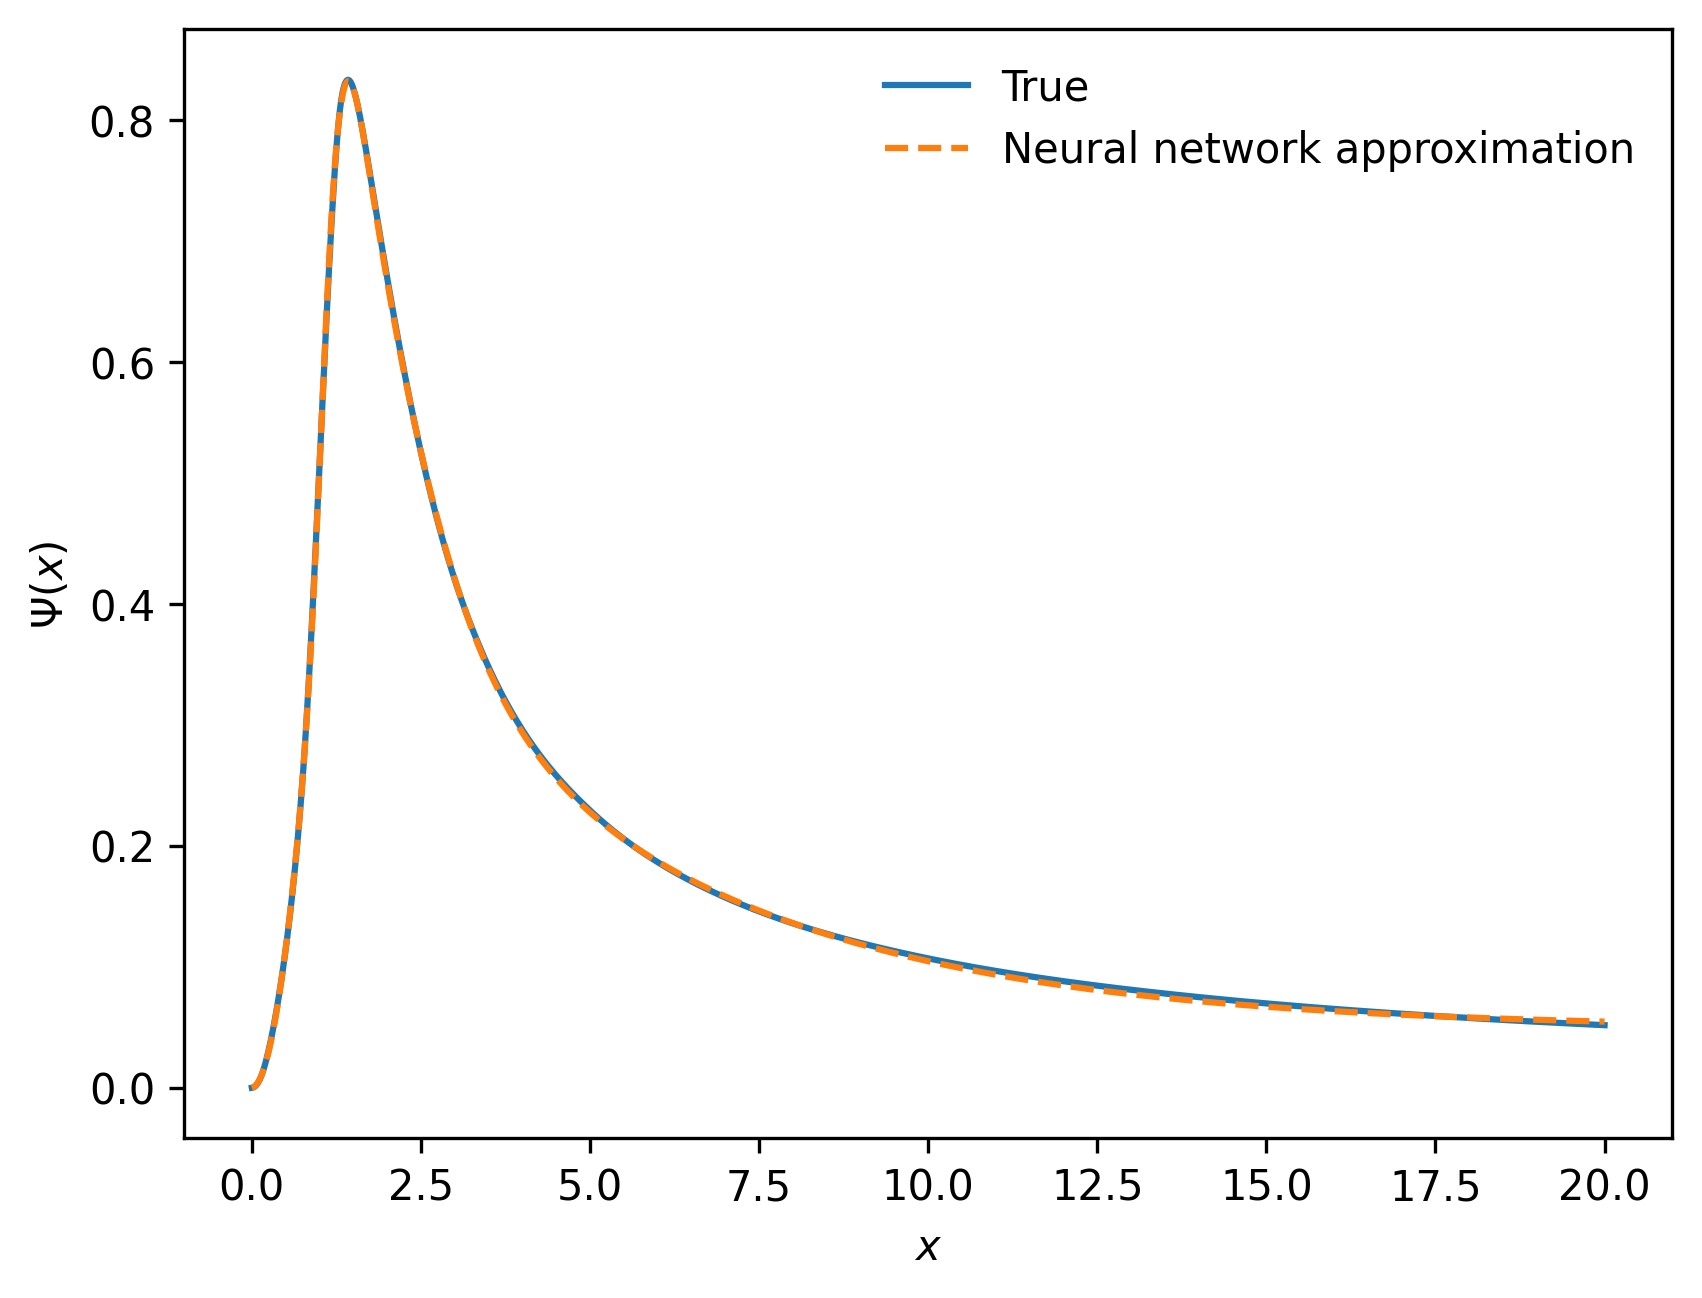

In [ ]:


# Optimize
optimizer = torch.optim.LBFGS(N.parameters())

# the closer function is required by LBFGS optimizer
def closure():
    optimizer.zero_grad()
    l = loss(x)
    l.backward()
    return l


for i in range(1000):
    optimizer.step(closure)



# Define the ODE function for analytical solution
def dPsi_dx(x, Psi):
    return np.exp(-x**2 / 2) * np.sin(x) -Psi**2 + x**2 * np.exp(-(x-1)**2 / 0.1)



# Solve using solve_ivp with default settings
solution = solve_ivp(
    dPsi_dx,
    [x_start, x_end],
    [Psi_0],
    dense_output=True
)

# Create dense output for plotting
x_dense = np.linspace(x_start, x_end, 1000)
Psi_dense = solution.sol(x_dense)[0]



#disable gradient tracking, which is unnecessary for plotting results.
with torch.no_grad():
    yy = Psi_app(torch.Tensor(x_dense)[:, None].to(device)).cpu().numpy()
# numpy arrays can only handle tensors that are on CPU



fig, ax = plt.subplots(dpi=300)
ax.plot(x_dense, Psi_dense, label='True')
ax.plot(x_dense, yy, '--', label='Neural network approximation')
ax.set_xlabel('$x$')
ax.set_ylabel('$Ψ(x)$')
plt.legend(frameon=False)

$$
\frac{d^2y}{dx^2}= -4x
$$

$$
y(-1)=0\text{ ; }y(1)=0
$$

$$
\text{solution = } \frac{-2(x^3-x)}{3}
$$

Solve_ivp cannot solve 2nd order ODE directly, its bit complicated to solve, so I used an equation which had a solution available.

In [4]:
# The collocation points
x = torch.Tensor(np.linspace(-1, 1, 1000)).reshape(-1,1)
x=x.to(device)

In [5]:
class Network2(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(1, 5)
        self.output_layer = nn.Linear(5, 1)



    def forward(self, x):
        layer_out = torch.sigmoid(self.hidden_layer(x))
        output = self.output_layer(layer_out)
        return output

N2 = Network2()

In [6]:
model=N2.to(device)

In [11]:
def g(x):
    return -4*x

def loss(x):
    x.requires_grad = True

    y_pred = N2(x)

    dy_dx = torch.autograd.grad(y_pred, x, grad_outputs=torch.ones_like(y_pred),
                                  create_graph=True)[0]
    y_double_prime = torch.autograd.grad(dy_dx, x, grad_outputs=torch.ones_like(dy_dx),
                                  create_graph=True)[0]

    return torch.mean( (y_double_prime - g(x))**2 ) + 0.5*(y[1] - 0)**2 + 0.5*(y[-1] - 0)**2

In [12]:

optimizer = torch.optim.LBFGS(N2.parameters(), lr=0.1)

x = torch.linspace(-1, 1, 100)
x = torch.Tensor(x).reshape(-1,1).to(device)

def g(x):
    return -4*x*torch.ones(100,1).to(device)

def loss(x):
    x.requires_grad = True
    y = N2(x)
    dy_dx = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    y_double_prime = torch.autograd.grad(dy_dx.sum(), x, create_graph=True)[0]

    return torch.mean( (y_double_prime - g(x))**2 ) + 0.5*(y[0, 0] - 0)**2 + 0.5*(y[-1, 0] - 0)**2

# Define the closure function required by LBFGS
def closure():
    optimizer.zero_grad()
    l = loss(x)
    l.backward()
    return l


epochs = 2000
for i in range(epochs):
    optimizer.step(closure)

    with torch.no_grad():             # numpy arrays can only handle tensors on CPU
      yy = N2(x).cpu().numpy()

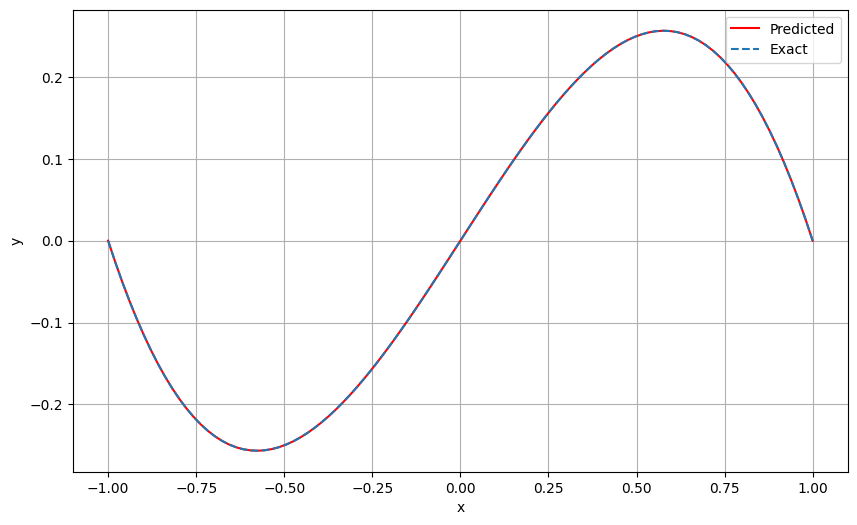

In [14]:
xx = torch.linspace(-1, 1, 100)[:, None].to(device)
with torch.no_grad():
    yy = N2(xx)
    # Calculate the exact solution here, ensuring no gradients are tracked.
    # The 'x' variable comes from the training cell and now has requires_grad=True
    exact_solution_values = (-2*(xx**3-x)/3)

plt.figure(figsize=(10, 6))
plt.plot(xx.cpu(), yy.cpu(), label="Predicted",color='red')
plt.plot(xx.cpu(), exact_solution_values.cpu(), '--', label="Exact")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()